# 2026 Córdoba Floods — Google Earth Engine Analysis (Fixed)

**Before running:** you'll need a Google Earth Engine account (free) registered at
[code.earthengine.google.com](https://code.earthengine.google.com), and a Google Cloud
project ID to pass to `ee.Initialize()`.

**Recommended:** Runtime → Restart runtime, then Run all, rather than running cells
out of order — several of today's debugging surprises came from stale cell state.


## Setup

In [1]:
!pip install earthengine-api geemap -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 39.7 MB/s eta 0:00:00


## Step 1 — Initialize Earth Engine

In [20]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import rasterio
import geopandas as gpd
from rasterio.features import rasterize, geometry_mask

from google.colab import drive

GEE_PROJECT = "ee-gee-username"

ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)

print("GEE initialized successfully")
print("Python EE version:", ee.__version__)

GEE initialized successfully
Python EE version: 1.7.35


## Step 2 — Define the study area

The Global Administrative Unit Layers (GAUL) is a standardized spatial dataset managed by the Food and Agriculture Organization (FAO) of the United Nations. It compiles, unifies, and disseminates high-quality geographic data representing sub-national administrative boundaries for all countries across the globe.

The FAO GAUL dataset divides global administrative boundaries into four distinct, hierarchical tiers starting from the international level down to local districts:The 4 GAUL LevelsLevel 0 (Global/National): Represents sovereign country borders and international boundaries.Level 1 (Primary Subnational): Represents major first-level political divisions like states, provinces, or regions.Level 2 (Secondary Subnational): Represents intermediate administrative areas like districts, counties, departments, or municipalities.Level 3 (Tertiary Subnational): Represents the smallest mapped local units, such as sub-districts, communes, or wards (available only for a subset of countries).

In [3]:
colombia_depts = ee.FeatureCollection("FAO/GAUL/2015/level1")
cordoba = colombia_depts.filter(
    ee.Filter.And(
        ee.Filter.eq("ADM0_NAME", "Colombia"),
        ee.Filter.eq("ADM1_NAME", "Cordoba")
    )
)
cordoba_geom = cordoba.geometry()
print("Córdoba area (km2):", round(cordoba_geom.area().divide(1e6).getInfo(), 1))

municipios = ee.FeatureCollection("FAO/GAUL/2015/level2")
monteria = municipios.filter(
    ee.Filter.And(
        ee.Filter.eq("ADM1_NAME", "Cordoba"),
        ee.Filter.eq("ADM2_NAME", "Monteria")
    )
)

print("Study area defined")

Córdoba area (km2): 25022.7
Study area defined


## Step 3 — Load Sentinel-1 SAR (pre/post flood)

Pre-flood: December 2025 dry-season baseline (14 scenes). Post-flood: narrowed to
`2026-02-08`–`2026-02-14` to isolate peak inundation, rather than averaging in
pre-peak scenes from earlier in the month.

In [4]:
s1_pre_collection = (ee.ImageCollection("COPERNICUS/S1_GRD")
            .filter(ee.Filter.eq("instrumentMode", "IW"))
            .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
            .filter(ee.Filter.eq("orbitProperties_pass", "DESCENDING"))
            .filterBounds(cordoba_geom)
            .filterDate("2025-12-01", "2025-12-31")
            .select("VV"))
print("Pre-flood scene count:", s1_pre_collection.size().getInfo())
s1_pre = s1_pre_collection.mean().clip(cordoba_geom)

s1_post_collection = (ee.ImageCollection("COPERNICUS/S1_GRD")
             .filter(ee.Filter.eq("instrumentMode", "IW"))
             .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
             .filter(ee.Filter.eq("orbitProperties_pass", "DESCENDING"))
             .filterBounds(cordoba_geom)
             .filterDate("2026-02-08", "2026-02-14")
             .select("VV"))
print("Post-flood scene count:", s1_post_collection.size().getInfo())
s1_post = s1_post_collection.mean().clip(cordoba_geom)

pre_stats  = s1_pre.reduceRegion(ee.Reducer.mean(), cordoba_geom, 30, maxPixels=1e10)
post_stats = s1_post.reduceRegion(ee.Reducer.mean(), cordoba_geom, 30, maxPixels=1e10)
print("Pre-flood mean VV (dB): ", round(pre_stats.getInfo()["VV"], 2))
print("Post-flood mean VV (dB):", round(post_stats.getInfo()["VV"], 2))

Pre-flood scene count: 14
Post-flood scene count: 3
Pre-flood mean VV (dB):  -9.24
Post-flood mean VV (dB): -9.12


## Sanity check — inspect the signal before thresholding

Whole-department percentiles will look weak (flooding is concentrated in the
floodplain, not spread evenly across the department's uplands and mountains).
This cell exists to *see* that, not to feed the final flood mask.

In [5]:
difference = s1_pre.subtract(s1_post)

diff_stats = difference.reduceRegion(
    reducer=ee.Reducer.percentile([5, 25, 50, 75, 95]),
    geometry=cordoba_geom, scale=30, maxPixels=1e10
)
print("Whole-department percentiles (dB):", diff_stats.getInfo())

Whole-department percentiles (dB): {'VV_p25': -1.7419184528615663, 'VV_p5': -3.7307159903908156, 'VV_p50': -0.2506866099236083, 'VV_p75': 1.2406971412772743, 'VV_p95': 3.2320208192565625}


Optional visual check — SAR difference layer over the department (blue = little/no change, red = strong backscatter drop = likely flood):

In [6]:
Map = geemap.Map()
Map.centerObject(cordoba_geom, 8)
Map.addLayer(difference, {"min": -5, "max": 10, "palette": ["blue", "white", "red"]}, "SAR difference")
Map.addLayer(cordoba_geom, {}, "Córdoba boundary", opacity=0.3)
Map

Map(center=[8.349950719125724, -75.79971270109952], controls=(WidgetControl(options=['position', 'transparent_…

## Step 4 — Detect flood extent

Change detection thresholded at 3 dB, masked by slope, **lowland elevation**, and
permanent water, then summarized per municipality.

The lowland mask is the fix that matters most here: it restricts the flood mask to
the bottom 15% of elevation in the department — the floodplain where flooding can
physically occur — instead of applying the threshold uniformly across mountains,
upland pasture, and lowland alike.

In [7]:
CHANGE_THRESHOLD = 3.0
flood_raw = difference.gt(CHANGE_THRESHOLD)

dem   = ee.Image("USGS/SRTMGL1_003").clip(cordoba_geom)
slope = ee.Terrain.slope(dem)

# Lowland mask - note the correct key: percentile reducer renames output to elevation_p15
elev_threshold = dem.reduceRegion(
    reducer=ee.Reducer.percentile([15]), geometry=cordoba_geom, scale=30, maxPixels=1e10
).get("elevation")   # this was right all along
low_mask = dem.lt(ee.Number(elev_threshold))

jrc_water = (ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
               .select("seasonality")
               .clip(cordoba_geom))

# Final flood mask - now actually includes the lowland mask
jrc_water_filled = jrc_water.unmask(0)   # no water history -> treat as 0, not no-data
permanent_water = jrc_water_filled.gt(10)

flood_mask = (flood_raw
              .And(slope.lt(5))
              .And(low_mask)
              .And(permanent_water.Not())
              .rename("flood"))

print("After full mask (dept-wide):", flood_mask.reduceRegion(
    ee.Reducer.sum(), cordoba_geom, 30, maxPixels=1e10).getInfo())

# Quick check: how much does each mask remove, at each stage
print("Raw threshold pixels:      ", flood_raw.reduceRegion(ee.Reducer.sum(), cordoba_geom, 30, maxPixels=1e10).getInfo())
print("After slope mask:          ", flood_raw.And(slope.lt(5)).reduceRegion(ee.Reducer.sum(), cordoba_geom, 30, maxPixels=1e10).getInfo())
print("After slope + lowland mask:", flood_raw.And(slope.lt(5)).And(low_mask).reduceRegion(ee.Reducer.sum(), cordoba_geom, 30, maxPixels=1e10).getInfo())


After full mask (dept-wide): {'flood': 649166.1490196078}
Raw threshold pixels:       {'VV': 1830458.5137254903}
After slope mask:           {'VV': 1338725.207843137}
After slope + lowland mask: {'VV': 662081.2470588235}


Zonal statistics — flooded area per municipality:

In [8]:
def get_flood_stats(feature):
    stats = flood_mask.reduceRegion(
        reducer   = ee.Reducer.sum().combine(ee.Reducer.count(), sharedInputs=True),
        geometry  = feature.geometry(),
        scale     = 30,
        maxPixels = 1e9
    )
    flood_px  = ee.Number(stats.get("flood_sum"))
    total_px  = ee.Number(stats.get("flood_count"))
    flood_pct = flood_px.divide(total_px).multiply(100)
    flood_km2 = flood_px.multiply(30*30).divide(1e6)
    return feature.set({
        "flood_pixels": flood_px,
        "flood_km2":    flood_km2,
        "flood_pct":    flood_pct,
        "municipio":    feature.get("ADM2_NAME"),
    })

municipios_cordoba = municipios.filter(ee.Filter.eq("ADM1_NAME", "Cordoba"))
flood_by_municipio = municipios_cordoba.map(get_flood_stats)

fc_list = flood_by_municipio.toList(100)
results = []
for i in range(fc_list.size().getInfo()):
    feat  = ee.Feature(fc_list.get(i))
    props = feat.toDictionary(["municipio", "flood_km2", "flood_pct"]).getInfo()
    results.append(props)

df = pd.DataFrame(results).sort_values("flood_km2", ascending=False)
print(df.head(10).to_string(index=False))
print(f"\nTotal flood extent: {df['flood_km2'].sum():.0f} km2")

 flood_km2  flood_pct              municipio
187.129892   6.051822               Monteria
118.839985  11.849170                 Lorica
 47.877208   2.186992                 Ayapel
 46.917145  13.837466                  Chima
 43.970545  12.123327 San Bernardo El Viento
 31.639271   6.396587             San Pelayo
 22.133259   3.416965         Cienaga De Oro
 22.078585   8.871476                 Cerete
 14.623376   2.924936             San Carlos
 12.588854  10.473927                  Momil

Total flood extent: 584 km2


## Step 5 — NDVI time series

Monthly cloud-masked Sentinel-2 composites, January 2025 to June 2026, to quantify
vegetation damage and recovery. A same-months-prior-year comparison is included to
separate flood impact from ordinary dry-season seasonality.

In [9]:
def mask_s2_clouds(image):
    qa = image.select("QA60")
    cloud_mask = (qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0)))
    return image.updateMask(cloud_mask).divide(10000)

def get_monthly_ndvi(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end   = start.advance(1, "month")
    s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(cordoba_geom)
            .filterDate(start, end)
            .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
            .map(mask_s2_clouds)
            .median()
            .clip(cordoba_geom))
    ndvi = s2.normalizedDifference(["B8", "B4"]).rename("NDVI")
    mean = ndvi.reduceRegion(ee.Reducer.mean(), cordoba_geom, 30, maxPixels=1e10).get("NDVI")
    return {"date": f"{year}-{month:02d}", "ndvi_mean": mean.getInfo()}

records = []
for year, month in [(2025, m) for m in range(1, 13)] + [(2026, m) for m in range(1, 7)]:
    try:
        records.append(get_monthly_ndvi(year, month))
    except Exception:
        pass

ndvi_df = pd.DataFrame(records)
ndvi_df["date"] = pd.to_datetime(ndvi_df["date"])
ndvi_df = ndvi_df.dropna()


Same Dec-Mar window, one year earlier — no flood event that year, to check how much of the dip is ordinary dry-season seasonality vs the flood itself:

In [10]:
records_prior_year = []
for y, m in [(2024, 12), (2025, 1), (2025, 2), (2025, 3)]:
    try:
        records_prior_year.append(get_monthly_ndvi(y, m))
    except Exception:
        pass

prior_df = pd.DataFrame(records_prior_year)
print(prior_df)
print()
print("If 2026's Feb/Mar NDVI is noticeably lower than the same months here,")
print("that's evidence of real flood impact beyond ordinary dry-season decline.")

      date  ndvi_mean
0  2024-12   0.631104
1  2025-01   0.570221
2  2025-02   0.432062
3  2025-03   0.501723

If 2026's Feb/Mar NDVI is noticeably lower than the same months here,
that's evidence of real flood impact beyond ordinary dry-season decline.


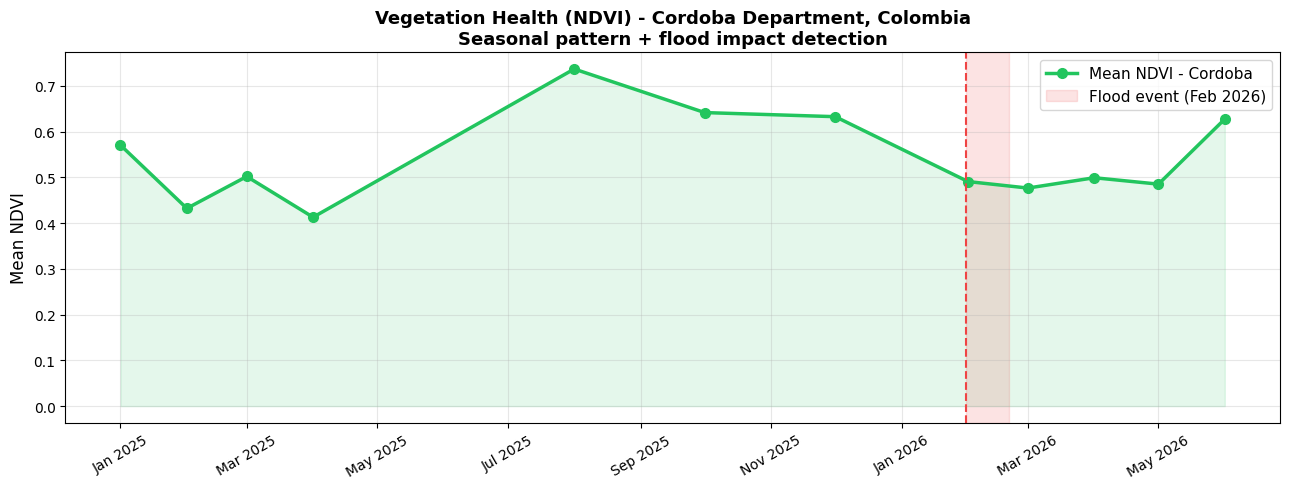

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ndvi_df.date, ndvi_df.ndvi_mean, "o-",
        color="#22C55E", linewidth=2.5, markersize=7, label="Mean NDVI - Cordoba")
ax.fill_between(ndvi_df.date, ndvi_df.ndvi_mean, alpha=0.12, color="#22C55E")
ax.axvspan(pd.Timestamp("2026-01-31"), pd.Timestamp("2026-02-20"),
           alpha=0.15, color="#EF4444", label="Flood event (Feb 2026)")
ax.axvline(pd.Timestamp("2026-01-31"), color="#EF4444", linestyle="--", linewidth=1.5)
ax.set_ylabel("Mean NDVI", fontsize=12)
ax.set_title("Vegetation Health (NDVI) - Cordoba Department, Colombia\n"
             "Seasonal pattern + flood impact detection", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cordoba_ndvi_timeseries.png", dpi=150)
plt.show()

## Step 6 — Statistics, visualization, and export

The pie chart below filters out any zero-count severity class before plotting —
this avoids overlapping "0%" labels stacking on top of each other, which happened
in the original version when a category had no members.

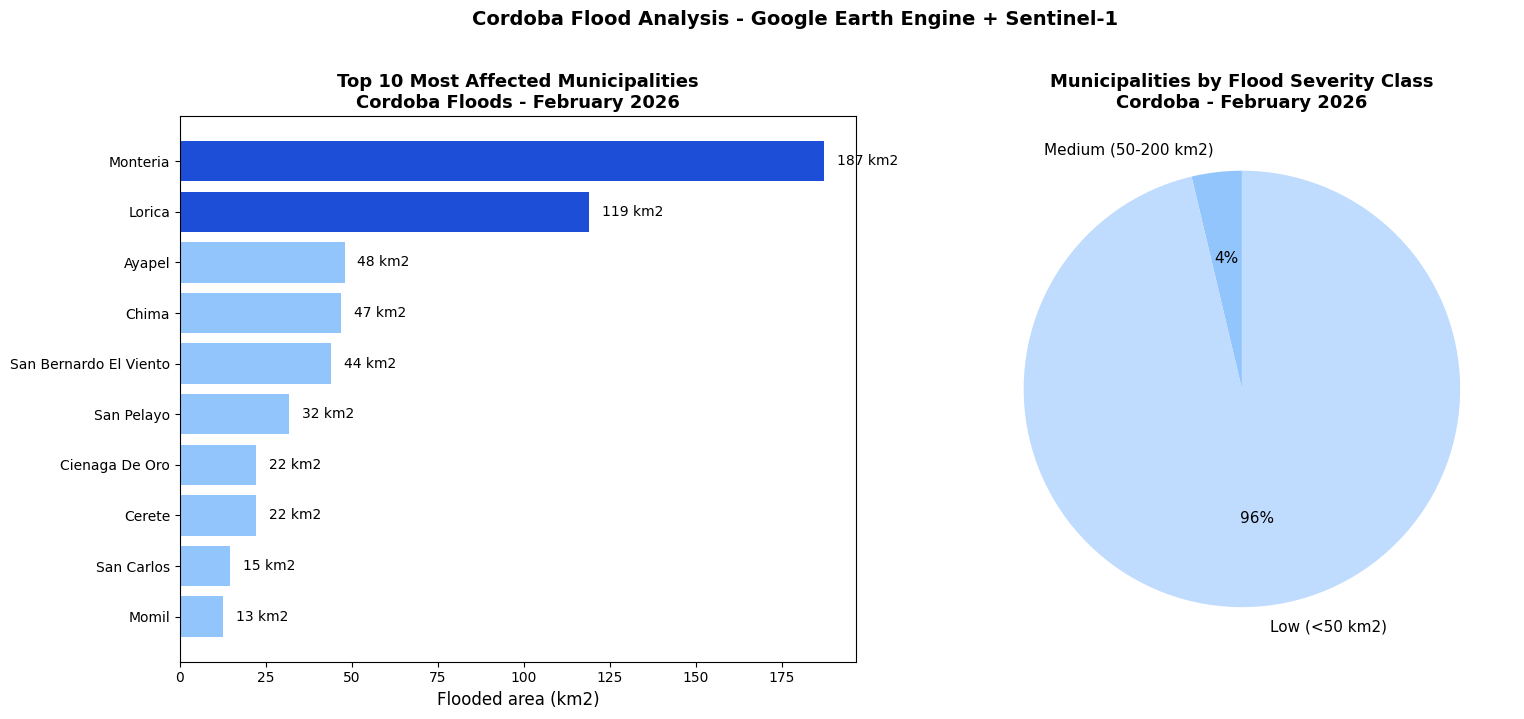

In [12]:
top10 = df.head(10)
colors = ["#1D4ED8" if v > 100 else "#93C5FD" for v in top10.flood_km2]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top10.municipio[::-1], top10.flood_km2[::-1], color=colors[::-1])
axes[0].set_xlabel("Flooded area (km2)", fontsize=12)
axes[0].set_title("Top 10 Most Affected Municipalities\nCordoba Floods - February 2026",
                  fontsize=13, fontweight="bold")
for i, v in enumerate(top10.flood_km2[::-1]):
    axes[0].text(v + max(top10.flood_km2)*0.02, i, f"{v:.0f} km2", va="center", fontsize=10)

labels_all = ["High (>200 km2)", "Medium (50-200 km2)", "Low (<50 km2)"]
sizes_all  = [
    (df.flood_km2 > 200).sum(),
    ((df.flood_km2 >= 50) & (df.flood_km2 <= 200)).sum(),
    (df.flood_km2 < 50).sum()
]
colors_p_all = ["#1D4ED8", "#93C5FD", "#BFDBFE"]

# Filter out empty categories - fixes the overlapping-label bug
labels   = [l for l, s in zip(labels_all, sizes_all) if s > 0]
sizes    = [s for s in sizes_all if s > 0]
colors_p = [c for c, s in zip(colors_p_all, sizes_all) if s > 0]

axes[1].pie(sizes, labels=labels, colors=colors_p, autopct="%1.0f%%",
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Municipalities by Flood Severity Class\nCordoba - February 2026",
                  fontsize=13, fontweight="bold")

plt.suptitle("Cordoba Flood Analysis - Google Earth Engine + Sentinel-1",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("cordoba_flood_stats.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
dist_water = (permanent_water
              .fastDistanceTransform(50)
              .sqrt()
              .rename("dist_water"))  # approx. pixel-distance-to-water, proxy for proximity

ndvi_pre = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
              .filterBounds(cordoba_geom)
              .filterDate("2025-12-01", "2025-12-31")
              .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
              .map(mask_s2_clouds)
              .median()
              .normalizedDifference(["B8", "B4"])
              .rename("ndvi_pre"))

feature_stack = (s1_pre.rename("vv_pre")
                  .addBands(s1_post.rename("vv_post"))
                  .addBands(difference.rename("vv_diff"))
                  .addBands(slope.rename("slope"))
                  .addBands(dem.rename("elevation"))
                  .addBands(dist_water)
                  .addBands(ndvi_pre)
                  .clip(cordoba_geom)
                  .toFloat())

task_features = ee.batch.Export.image.toDrive(
    image          = feature_stack,
    description    = "Cordoba_ML_Features_Feb2026",
    folder         = "GEE_Exports",
    fileNamePrefix = "cordoba_ml_features",
    region         = cordoba_geom,
    scale          = 30,
    crs            = "EPSG:4326",
    maxPixels      = 1e10
)
task_features.start()
print("Feature stack export started — check task status before continuing to Step 10")

Feature stack export started — check task status before continuing to Step 10


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
print(ref_gdf.columns)

Index(['geometry'], dtype='object')


In [29]:
drive.mount("/content/drive")

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
ems_dir = Path("/content/EMSR865_AOI01_DEL_MONIT02_v1")

pred_path = Path("/content/drive/MyDrive/GEE_exports/cordoba_flood_2026.tif")

ref_path = Path("/content/EMSR865_AOI01_DEL_MONIT02_observedEventA_v1.shp")

aoi_path = Path("/content/EMSR865_AOI01_DEL_MONIT02_areaOfInterestA_v1.shp")

# ------------------------------------------------------------
# Check files
# ------------------------------------------------------------
assert pred_path.exists(), f"Missing raster:\n{pred_path}"
assert ref_path.exists(), f"Missing reference shapefile:\n{ref_path}"
assert aoi_path.exists(), f"Missing AOI shapefile:\n{aoi_path}"

# ------------------------------------------------------------
# Read predicted flood map
# ------------------------------------------------------------
with rasterio.open(pred_path) as src:

    predicted = src.read(1)

    transform = src.transform
    out_shape = src.shape
    raster_crs = src.crs

# Convert to boolean
predicted = predicted.astype(bool)

# ------------------------------------------------------------
# Read EMS reference polygons
# ------------------------------------------------------------
ref_gdf = gpd.read_file(ref_path)

print(f"Reference polygons: {len(ref_gdf)}")

ref_gdf = ref_gdf.to_crs(raster_crs)

reference = rasterize(
    [(geom, 1) for geom in ref_gdf.geometry],
    out_shape=out_shape,
    transform=transform,
    fill=0,
    dtype="uint8",
).astype(bool)

# ------------------------------------------------------------
# Read EMS Area of Interest
# ------------------------------------------------------------
aoi_gdf = gpd.read_file(aoi_path).to_crs(raster_crs)

aoi_mask = ~geometry_mask(
    aoi_gdf.geometry,
    out_shape=out_shape,
    transform=transform,
    invert=False,
)

# ------------------------------------------------------------
# Compare only inside AOI
# ------------------------------------------------------------
pred = predicted[aoi_mask]
ref = reference[aoi_mask]

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------
TP = np.sum(pred & ref)
FP = np.sum(pred & ~ref)
FN = np.sum(~pred & ref)
TN = np.sum(~pred & ~ref)

total = TP + FP + FN + TN

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
overall_accuracy = (TP + TN) / total

precision = TP / (TP + FP) if (TP + FP) else np.nan
recall = TP / (TP + FN) if (TP + FN) else np.nan

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall)
    else np.nan
)

iou = TP / (TP + FP + FN) if (TP + FP + FN) else np.nan

# Cohen's Kappa
po = overall_accuracy

pe = (
    ((TP + FP) * (TP + FN) +
     (FN + TN) * (FP + TN))
    / (total ** 2)
)

kappa = (po - pe) / (1 - pe)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------
print("\n")
print("=" * 65)
print("VALIDATION OF SAR FLOOD MAP")
print("Reference: Copernicus EMSR865 Observed Event A")
print("=" * 65)

print("\nConfusion Matrix\n")

print(f"{'':15s}Reference Flood   Reference Dry")
print(f"Pred Flood {TP:12,d} {FP:15,d}")
print(f"Pred Dry   {FN:12,d} {TN:15,d}")

print("\nMetrics")
print("-" * 40)

print(f"Overall Accuracy : {overall_accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-score         : {f1:.4f}")
print(f"IoU              : {iou:.4f}")
print(f"Cohen's Kappa    : {kappa:.4f}")
print(f"Pixels evaluated : {total:,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reference polygons: 4470


VALIDATION OF SAR FLOOD MAP
Reference: Copernicus EMSR865 Observed Event A

Confusion Matrix

               Reference Flood   Reference Dry
Pred Flood      152,802         407,638
Pred Dry         72,238       4,093,721

Metrics
----------------------------------------
Overall Accuracy : 0.8985
Precision        : 0.2726
Recall           : 0.6790
F1-score         : 0.3891
IoU              : 0.2415
Cohen's Kappa    : 0.3445
Pixels evaluated : 4,726,399


In [36]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


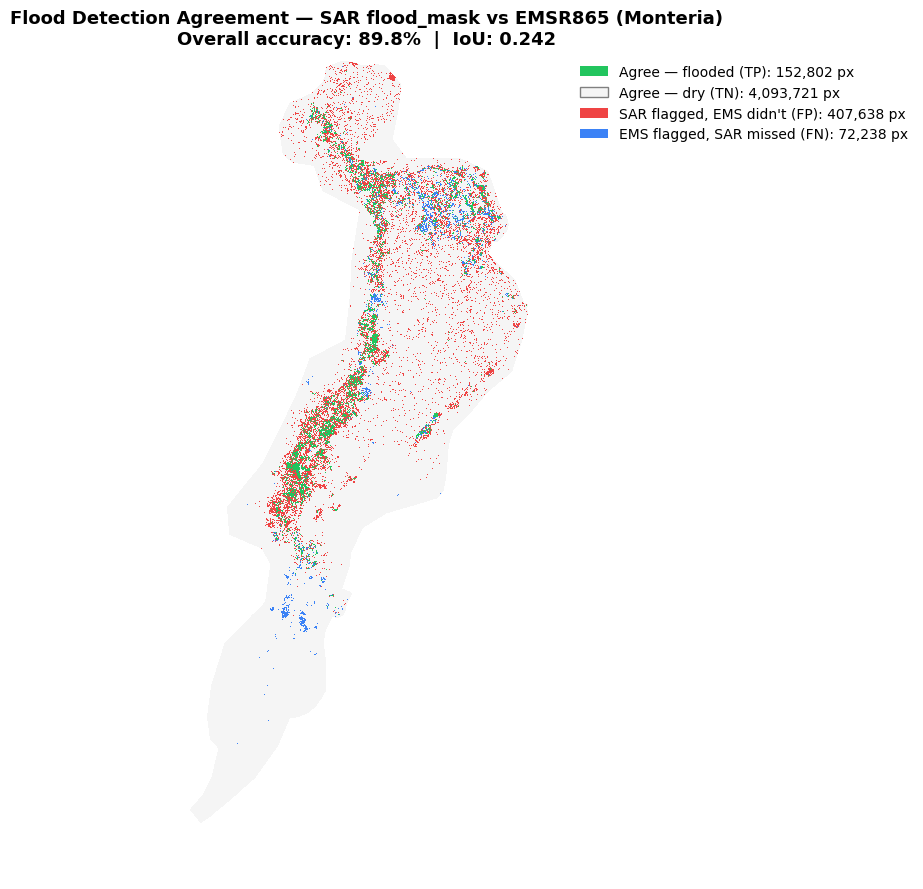

In [44]:
class_map = np.zeros(out_shape, dtype=np.uint8)
class_map[(~predicted) & (~reference)] = 0   # TN
class_map[(~predicted) & (reference)]  = 1   # FN — missed by SAR
class_map[(predicted) & (~reference)]  = 2   # FP — false alarm
class_map[(predicted) & (reference)]   = 3   # TP — agreement
class_map[~aoi_mask] = 255                    # outside AOI, mask out of plot

# Crop to where the action is: bounding box of reference ∪ predicted, +10% padding
flood_rows, flood_cols = np.where((predicted | reference) & aoi_mask)
pad_r = int((flood_rows.max() - flood_rows.min()) * 0.1)
pad_c = int((flood_cols.max() - flood_cols.min()) * 0.1)
r0, r1 = max(flood_rows.min() - pad_r, 0), min(flood_rows.max() + pad_r, out_shape[0])
c0, c1 = max(flood_cols.min() - pad_c, 0), min(flood_cols.max() + pad_c, out_shape[1])

crop = class_map[r0:r1, c0:c1].astype(float)
crop[crop == 255] = np.nan  # transparent outside AOI

colors = ["#F5F5F5", "#3B82F6", "#EF4444", "#22C55E"]  # TN, FN, FP, TP
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(crop, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")
ax.set_title("Flood Detection Agreement — SAR flood_mask vs EMSR865 (Monteria)\n"
             f"Overall accuracy: {overall_accuracy:.1%}  |  IoU: {iou:.3f}",
             fontsize=13, fontweight="bold")
ax.axis("off")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#22C55E", label=f"Agree — flooded (TP): {TP:,} px"),
    Patch(facecolor="#F5F5F5", edgecolor="gray", label=f"Agree — dry (TN): {TN:,} px"),
    Patch(facecolor="#EF4444", label=f"SAR flagged, EMS didn't (FP): {FP:,} px"),
    Patch(facecolor="#3B82F6", label=f"EMS flagged, SAR missed (FN): {FN:,} px"),
]
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1),
          fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("cordoba_flood_validation_map.png", dpi=150, bbox_inches="tight")
plt.show()

precision_threshold = precision
recall_threshold = recall
iou_threshold = iou

In [31]:
feat_path = "/content/drive/MyDrive/GEE_exports/cordoba_ml_features.tif"

with rasterio.open(feat_path) as src:
    feature_stack_arr = src.read()

print(feature_stack_arr.shape)  # should now be (7, 7780, 6479) — 7 bands, same H/W as before

(7, 7780, 6479)


In [38]:
feat_path = "/content/drive/MyDrive/GEE_exports/cordoba_ml_features.tif"
with rasterio.open(feat_path) as src:
    feature_stack_arr = src.read()

band_names = ["vv_pre", "vv_post", "vv_diff", "slope", "elevation", "dist_water", "ndvi_pre"]
assert feature_stack_arr.shape[1:] == out_shape, "Grid mismatch — check export region/scale/crs matches flood_mask"

rows, cols = np.where(aoi_mask)
data = {name: feature_stack_arr[i][rows, cols] for i, name in enumerate(band_names)}
data["label"] = reference[rows, cols].astype(int)
data["row"], data["col"] = rows, cols

df_ml = pd.DataFrame(data).dropna()
print(df_ml.shape, "| flooded fraction:", df_ml["label"].mean().round(4))

(4573673, 10) | flooded fraction: 0.0488


In [33]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00


Train: 3,716,867 px (5.6% flooded)
Test:  856,806 px (1.6% flooded)
0:	learn: 0.6407604	test: 0.6198136	best: 0.6198136 (0)	total: 599ms	remaining: 4m 58s
100:	learn: 0.2417539	test: 0.1073425	best: 0.1072057 (98)	total: 58s	remaining: 3m 49s
200:	learn: 0.2346848	test: 0.1097059	best: 0.1071066 (141)	total: 1m 54s	remaining: 2m 50s
300:	learn: 0.2310701	test: 0.1181479	best: 0.1071066 (141)	total: 2m 51s	remaining: 1m 53s
400:	learn: 0.2278967	test: 0.1273622	best: 0.1071066 (141)	total: 3m 51s	remaining: 57s
499:	learn: 0.2252923	test: 0.1358960	best: 0.1071066 (141)	total: 4m 47s	remaining: 0us

bestTest = 0.1071065975
bestIteration = 141

Shrink model to first 142 iterations.

CatBoost — Precision: 0.329  Recall: 0.935  IoU: 0.322  AUC: 0.989
Threshold method — Precision: 0.329  Recall: 0.935  IoU: 0.242


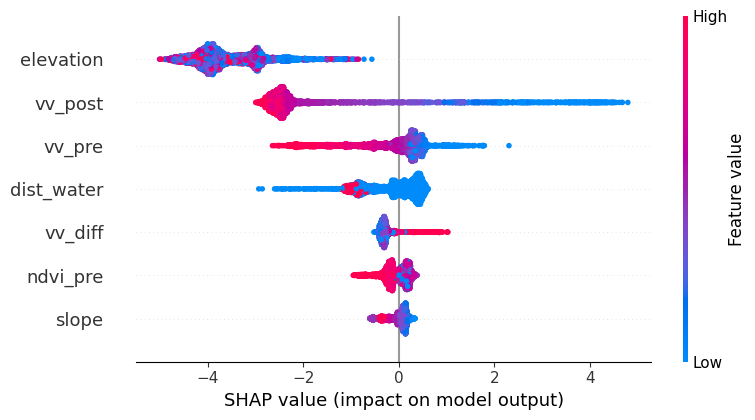

In [45]:

N_BLOCKS = 10
df_ml["lat_block"] = pd.cut(df_ml["row"], bins=N_BLOCKS, labels=False)
test_blocks = df_ml["lat_block"].max() - np.arange(3)  # holds out one contiguous end of the AOI
train_df = df_ml[~df_ml["lat_block"].isin(test_blocks)]
test_df  = df_ml[df_ml["lat_block"].isin(test_blocks)]

print(f"Train: {len(train_df):,} px ({train_df['label'].mean():.1%} flooded)")
print(f"Test:  {len(test_df):,} px ({test_df['label'].mean():.1%} flooded)")

from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

feature_cols = band_names
X_train, y_train = train_df[feature_cols], train_df["label"]
X_test,  y_test  = test_df[feature_cols],  test_df["label"]

model = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.05,
    auto_class_weights="Balanced", random_seed=42, verbose=100
)
model.fit(X_train, y_train, eval_set=(X_test, y_test))

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision, recall = tp/(tp+fp), tp/(tp+fn)
iou_ml = tp/(tp+fp+fn)

print(f"\nCatBoost — Precision: {precision:.3f}  Recall: {recall:.3f}  IoU: {iou_ml:.3f}  AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(
    f"Threshold method — Precision: {precision_threshold:.3f}  "
    f"Recall: {recall_threshold:.3f}  "
    f"IoU: {iou_threshold:.3f}"
)

"""## ML Track — Step 13: Feature importance (SHAP)"""

import shap

sample = X_test.sample(min(5000, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, show=True)

## Validation

Compare your flood map against official reference data:

- **Copernicus EMS EMSR865** — [mapping.emergency.copernicus.eu](https://mapping.emergency.copernicus.eu) — the official rapid mapping product for this exact event.
- **JRC Global Surface Water** — [global-surface-water.appspot.com](https://global-surface-water.appspot.com) — baseline permanent water extent.
- **UNGRD Colombia** — [portal.gestiondelriesgo.gov.co](https://portal.gestiondelriesgo.gov.co) — affected municipality lists for ground-truth comparison.

A good result for this type of SAR flood detection typically achieves overall accuracy
above 85% against reference flood perimeters. This is the next real step — everything
above gets you a defensible flood mask, but "defensible" and "validated" aren't the
same thing until it's checked against an independent reference.

---
*Companion notebook for the EcoGeo Tutor tutorial on rcafe.vercel.app*
